# bias_std_turn_5d 因子

该因子衡量股票最近5个交易日的换手率波动，相对于过去2年换手率波动水平的偏离程度。

$$
\text{bias\_std\_turn\_5d}_{i,t}
=
\frac{
\operatorname{Std}\left(\text{Turnover}_{i,t-4:t}\right)
}{
\operatorname{Std}\left(\text{Turnover}_{i,t-L+1:t}\right)
}
-1
$$

其中：

- $i$：股票；
- $t$：因子计算日；
- $\text{Turnover}_{i,t}$：股票 $i$ 在交易日 $t$ 的日换手率；
- $L$：过去2年对应的交易日数量，通常取约504个交易日；
- 分子：最近5个有效交易日换手率的标准差；
- 分母：最近2年有效日换手率的标准差。

数据处理规则

1. 换手率为0的日期不参与标准差计算。
2. 停牌日期不作为有效观察值。
3. 分母为0或有效样本不足时，将因子值设置为缺失。
4. 因子计算只能使用截至交易日 $t$ 收盘已经获得的数据。
5. 在 $t$ 日收盘后形成信号，最早于 $t+1$ 交易日开盘交易。

因子方向

该因子与未来收益呈负相关，即因子值越低，股票未来预期收益越高。

## 原始因子基础指标计算

[1/5] 查询 BigQuant 每 20 个交易日截面：2022-01-01 至 2026-06-30，滚动窗口=5/504个交易日
      返回 288,109 行、55 个截面，耗时 13.7 秒
[2/5] 构造相邻 20 交易日截面的收益标签，并过滤基础股票池
      有效样本 202,894 行，信号期 2022-01-04 至 2026-05-26
[3/5] 逐月计算基础指标 | IC暴露=neutralized | 最小截面=80
      已完成 12/54 个截面
      已完成 24/54 个截面
      已完成 36/54 个截面
      已完成 48/54 个截面
      已完成 54/54 个截面
      得到 54 个有效截面，耗时 18.5 秒
[4/5] 汇总基础指标


,因子名称,因子含义,IC口径,截面周期,收益周期,有效截面数,平均样本数,IC均值,RankIC均值,ICIR,RankICIR,因子收益率均值,t均值
0,bias_std_turn_5d,5日换手率标准差 / 两年换手率标准差 - 1（原始方向，低值优）,行业、市值中性化,每20个交易日,本次截面至下一次截面（20个交易日）,54,3757,-4.23%,-6.84%,-0.642,-1.068,-0.35%,-2.378


[5/5] 绘制每 20 交易日 IC / RankIC 时序图


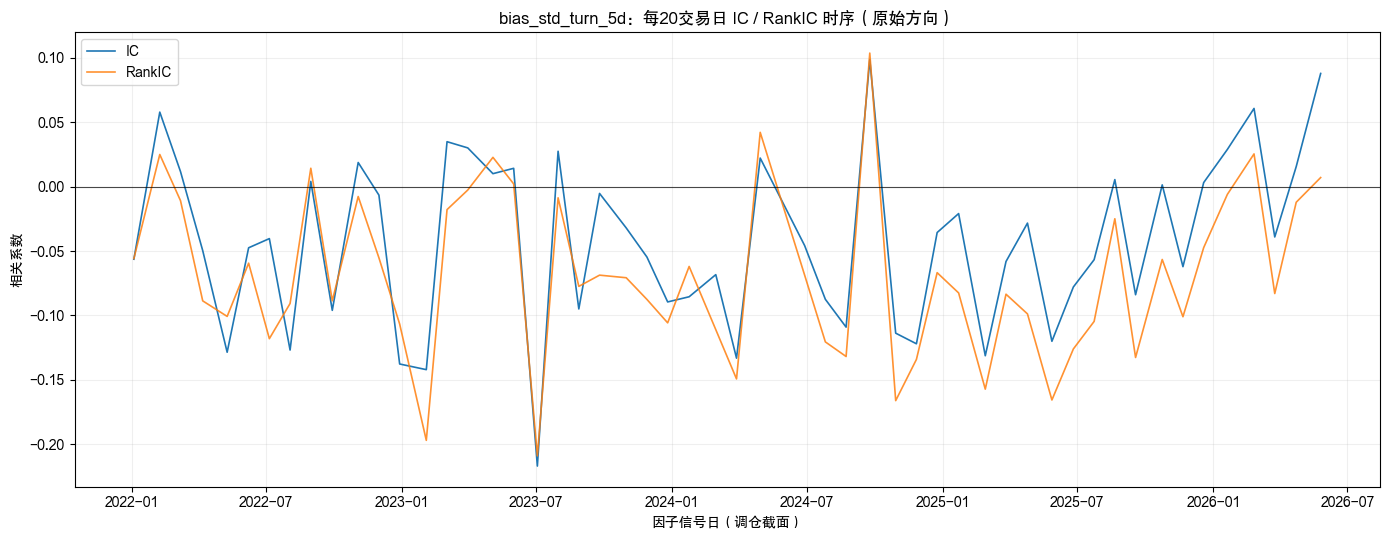

完成。factor_return 为每20个交易日的小数收益单位；原始因子低值优时，IC、RankIC、因子收益率出现负值是方向含义，不是计算错误。


In [1]:
"""
BigQuant：原始 bias_std_turn_5d 因子基础指标测试

因子定义
--------
bias_std_turn_5d = std(turn, 5个交易日) / std(turn, 504个交易日) - 1

计算滚动标准差时剔除 turn <= 0 的观测。因子保持研报中的原始方向，不乘 -1；
因此若“低值优”在样本期成立，IC、RankIC 和因子收益率通常应为负。

评价口径
--------
1. 从 START_DATE 起，每隔 N 个交易日形成一次因子暴露；
2. 标签为本次调仓日收盘到下一次调仓日收盘的收益率；
3. 因子先做截面 MAD 去极值和标准化；
4. 默认将因子对 log(总市值) 和行业哑变量回归，使用残差计算 IC/RankIC；
5. 因子收益率使用横截面 WLS：下一月收益 ~ 因子 + log(总市值) + 行业；
   权重为 sqrt(流通市值)，报告回归中因子系数及其 t 值；
6. ICIR、RankICIR 均为均值 / 时间序列样本标准差，不做年化。

代码只输出研究结果，不自动保存运行结果到磁盘。
"""

import time
from typing import Dict, Optional, Tuple

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd

from bigquant import dai


# =========================
# 可修改参数
# =========================
START_DATE = "2022-01-01"
END_DATE = "2026-06-30"

# 截面/调仓周期。20 表示从区间内首个交易日起，每 20 个交易日取一个截面。
REBALANCE_EVERY_N_TRADING_DAYS = 20

SHORT_WINDOW = 5
LONG_WINDOW = 504              # 约两个交易年
QUERY_LOOKBACK_DAYS = 850      # 给 504 日滚动窗口预留充足自然日
MIN_LIST_DAYS = 730            # 避免长期标准差被极短上市历史主导

MAD_MULTIPLIER = 5.0
MIN_CROSS_SECTION = 80

# "neutralized"：与研报更接近，IC 使用行业、市值中性化后的因子暴露
# "raw"：IC 使用仅经 MAD 去极值、标准化的原始因子暴露
IC_EXPOSURE_MODE = "neutralized"

# 研报因子收益率回归使用 sqrt(流通市值) 权重；设为 False 可切换为 OLS
USE_WLS_FOR_FACTOR_RETURN = True
PROGRESS_EVERY = 12


FACTOR_NAME = "bias_std_turn_5d"
FACTOR_DESCRIPTION = "5日换手率标准差 / 两年换手率标准差 - 1（原始方向，低值优）"


def _validate_parameters() -> None:
    if SHORT_WINDOW < 2:
        raise ValueError("SHORT_WINDOW 必须至少为 2")
    if LONG_WINDOW <= SHORT_WINDOW:
        raise ValueError("LONG_WINDOW 必须大于 SHORT_WINDOW")
    if MIN_CROSS_SECTION < 10:
        raise ValueError("MIN_CROSS_SECTION 不应小于 10")
    if not isinstance(REBALANCE_EVERY_N_TRADING_DAYS, int):
        raise TypeError("REBALANCE_EVERY_N_TRADING_DAYS 必须是整数")
    if REBALANCE_EVERY_N_TRADING_DAYS < 1:
        raise ValueError("REBALANCE_EVERY_N_TRADING_DAYS 必须至少为 1")
    if IC_EXPOSURE_MODE not in {"raw", "neutralized"}:
        raise ValueError("IC_EXPOSURE_MODE 只能为 'raw' 或 'neutralized'")


def _date_with_offset(date: str, days: int) -> str:
    return (pd.Timestamp(date) + pd.Timedelta(days=days)).strftime("%Y-%m-%d")


def query_rebalance_panel() -> pd.DataFrame:
    """查询每 N 个交易日的截面，并在数据库端计算滚动换手率标准差。"""
    query_start = _date_with_offset(START_DATE, -QUERY_LOOKBACK_DAYS)
    # 查询范围须覆盖 END_DATE 后至少一个完整 N 日周期，供最后一期生成标签。
    label_buffer_days = max(45, 2 * REBALANCE_EVERY_N_TRADING_DAYS + 20)
    query_end = _date_with_offset(END_DATE, label_buffer_days)

    sql = f"""
    WITH trading_dates AS (
        SELECT DISTINCT date
        FROM cn_stock_prefactors
        WHERE date >= '{START_DATE}'
          AND date <= '{query_end}'
    ),
    numbered_trading_dates AS (
        SELECT
            date,
            row_number() OVER (ORDER BY date) AS trading_day_number
        FROM trading_dates
    ),
    selected_dates AS (
        SELECT
            date,
            row_number() OVER (ORDER BY date) AS rebalance_index
        FROM numbered_trading_dates
        WHERE mod(trading_day_number - 1, {REBALANCE_EVERY_N_TRADING_DAYS}) = 0
    ),
    daily_factor AS (
        SELECT
            date,
            instrument,
            close,
            total_market_cap,
            float_market_cap,
            sw2014_level1 AS industry,
            st_status,
            suspended,
            list_days,
            m_stddev(if(turn > 0, turn, NULL), {SHORT_WINDOW}) AS turn_std_short,
            m_stddev(if(turn > 0, turn, NULL), {LONG_WINDOW}) AS turn_std_long
        FROM cn_stock_prefactors
    )
    SELECT
        f.date,
        d.rebalance_index,
        f.instrument,
        f.close,
        f.total_market_cap,
        f.float_market_cap,
        f.industry,
        f.st_status,
        f.suspended,
        f.list_days,
        f.turn_std_short,
        f.turn_std_long,
        f.turn_std_short / nullif(f.turn_std_long, 0) - 1 AS {FACTOR_NAME}
    FROM daily_factor f
    INNER JOIN selected_dates d
        ON f.date = d.date
    ORDER BY f.date, f.instrument
    """

    print(
        f"[1/5] 查询 BigQuant 每 {REBALANCE_EVERY_N_TRADING_DAYS} 个交易日截面："
        f"{START_DATE} 至 {END_DATE}，滚动窗口={SHORT_WINDOW}/{LONG_WINDOW}个交易日"
    )
    started = time.time()
    result = dai.query(
        sql,
        filters={"date": [query_start, query_end]},
    ).df()
    if result is None or result.empty:
        raise ValueError(
            "BigQuant 查询结果为空。请检查日期范围、数据权限以及 "
            "cn_stock_prefactors 中 turn/sw2014_level1 等字段是否可用。"
        )

    result["date"] = pd.to_datetime(result["date"])
    print(
        f"      返回 {len(result):,} 行、{result['date'].nunique():,} 个截面，"
        f"耗时 {time.time() - started:.1f} 秒"
    )
    return result


def add_next_rebalance_return(panel: pd.DataFrame) -> pd.DataFrame:
    """添加下一调仓日收益，并严格排除股票缺失导致的跨期标签。"""
    data = panel.copy()
    data = data.sort_values(["instrument", "date"])

    by_stock = data.groupby("instrument", sort=False)
    data["return_end_date"] = by_stock["date"].shift(-1)
    data["next_rebalance_close"] = by_stock["close"].shift(-1)
    data["next_rebalance_index"] = by_stock["rebalance_index"].shift(-1)

    # 股票若在紧邻的下一调仓截面缺失，不能把更远一期误作 N 日标签。
    is_exact_next_period = data["next_rebalance_index"] == data["rebalance_index"] + 1

    data["forward_return"] = np.where(
        is_exact_next_period,
        data["next_rebalance_close"] / data["close"] - 1.0,
        np.nan,
    )

    signal_start = pd.Timestamp(START_DATE)
    signal_end = pd.Timestamp(END_DATE)
    data = data.loc[data["date"].between(signal_start, signal_end)].copy()

    # 最后一个无法取得完整下一调仓日收益的截面会在此自然剔除。
    data = data.loc[data["forward_return"].notna()].copy()
    return data


def mad_winsorize_and_zscore(values: pd.Series) -> pd.Series:
    """截面中位数/MAD去极值后标准化；不改变因子方向。"""
    x = pd.to_numeric(values, errors="coerce").astype(float)
    valid = np.isfinite(x)
    result = pd.Series(np.nan, index=x.index, dtype=float)
    if valid.sum() < 3:
        return result

    xv = x.loc[valid]
    median = xv.median()
    mad = (xv - median).abs().median()

    if np.isfinite(mad) and mad > 0:
        lower = median - MAD_MULTIPLIER * mad
        upper = median + MAD_MULTIPLIER * mad
        xv = xv.clip(lower, upper)

    std = xv.std(ddof=1)
    if not np.isfinite(std) or std <= 0:
        return result
    result.loc[valid] = (xv - xv.mean()) / std
    return result


def _industry_design(industry: pd.Series) -> pd.DataFrame:
    values = industry.fillna("UNKNOWN").astype(str)
    return pd.get_dummies(values, prefix="industry", drop_first=True, dtype=float)


def neutralize_factor(
    factor_z: pd.Series,
    log_market_cap: pd.Series,
    industry: pd.Series,
) -> pd.Series:
    """用 OLS 剔除 log(总市值) 和行业对因子暴露的线性影响。"""
    design = pd.DataFrame(
        {
            "intercept": 1.0,
            "log_market_cap": pd.to_numeric(log_market_cap, errors="coerce"),
        },
        index=factor_z.index,
    )
    design = pd.concat([design, _industry_design(industry)], axis=1)
    y = pd.to_numeric(factor_z, errors="coerce")
    valid = np.isfinite(y) & np.isfinite(design).all(axis=1)

    residual = pd.Series(np.nan, index=factor_z.index, dtype=float)
    if valid.sum() <= design.shape[1] + 2:
        return residual

    x_array = design.loc[valid].to_numpy(dtype=float)
    y_array = y.loc[valid].to_numpy(dtype=float)
    beta = np.linalg.lstsq(x_array, y_array, rcond=None)[0]
    residual.loc[valid] = y_array - x_array @ beta
    return mad_winsorize_and_zscore(residual)


def weighted_factor_regression(
    returns: pd.Series,
    factor_z: pd.Series,
    log_market_cap: pd.Series,
    industry: pd.Series,
    float_market_cap: pd.Series,
) -> Tuple[float, float]:
    """截面回归并返回因子系数和带符号 t 值。"""
    design = pd.DataFrame(
        {
            "intercept": 1.0,
            "factor": pd.to_numeric(factor_z, errors="coerce"),
            "log_market_cap": pd.to_numeric(log_market_cap, errors="coerce"),
        },
        index=factor_z.index,
    )
    design = pd.concat([design, _industry_design(industry)], axis=1)
    y = pd.to_numeric(returns, errors="coerce")
    cap = pd.to_numeric(float_market_cap, errors="coerce")

    valid = np.isfinite(y) & np.isfinite(design).all(axis=1)
    if USE_WLS_FOR_FACTOR_RETURN:
        valid &= np.isfinite(cap) & (cap > 0)

    x = design.loc[valid].to_numpy(dtype=float)
    y_array = y.loc[valid].to_numpy(dtype=float)
    n_obs, n_params = x.shape
    if n_obs <= n_params + 2:
        return np.nan, np.nan

    if USE_WLS_FOR_FACTOR_RETURN:
        # 回归目标权重为 sqrt(流通市值)。WLS变换需要再取一次平方根。
        regression_weight = np.sqrt(cap.loc[valid].to_numpy(dtype=float))
        root_weight = np.sqrt(regression_weight)
        x_fit = x * root_weight[:, None]
        y_fit = y_array * root_weight
    else:
        x_fit = x
        y_fit = y_array

    xtx_inv = np.linalg.pinv(x_fit.T @ x_fit)
    beta = xtx_inv @ x_fit.T @ y_fit
    residual = y_fit - x_fit @ beta
    degrees_of_freedom = n_obs - n_params
    residual_variance = float(residual @ residual) / degrees_of_freedom
    covariance = residual_variance * xtx_inv

    factor_beta = float(beta[1])
    factor_se = float(np.sqrt(max(covariance[1, 1], 0.0)))
    factor_t = factor_beta / factor_se if factor_se > 0 else np.nan
    return factor_beta, factor_t


def calculate_cross_section_metrics(section: pd.DataFrame) -> Optional[Dict]:
    """计算单个调仓截面的 IC、RankIC、因子收益率和 t 值。"""
    required = [
        FACTOR_NAME,
        "forward_return",
        "total_market_cap",
        "float_market_cap",
        "industry",
    ]
    sample = section.dropna(subset=required).copy()
    sample = sample.loc[
        np.isfinite(sample[FACTOR_NAME])
        & np.isfinite(sample["forward_return"])
        & (sample["total_market_cap"] > 0)
        & (sample["float_market_cap"] > 0)
    ].copy()
    if len(sample) < MIN_CROSS_SECTION:
        return None

    sample["factor_z"] = mad_winsorize_and_zscore(sample[FACTOR_NAME])
    sample["log_market_cap"] = np.log(sample["total_market_cap"].astype(float))
    sample = sample.dropna(subset=["factor_z", "log_market_cap"])
    if len(sample) < MIN_CROSS_SECTION:
        return None

    if IC_EXPOSURE_MODE == "neutralized":
        sample["ic_exposure"] = neutralize_factor(
            sample["factor_z"], sample["log_market_cap"], sample["industry"]
        )
    else:
        sample["ic_exposure"] = sample["factor_z"]

    ic_sample = sample.dropna(subset=["ic_exposure", "forward_return"])
    if len(ic_sample) < MIN_CROSS_SECTION:
        return None

    ic = ic_sample["ic_exposure"].corr(ic_sample["forward_return"], method="pearson")
    rank_ic = ic_sample["ic_exposure"].corr(
        ic_sample["forward_return"], method="spearman"
    )
    factor_return, t_value = weighted_factor_regression(
        returns=sample["forward_return"],
        factor_z=sample["factor_z"],
        log_market_cap=sample["log_market_cap"],
        industry=sample["industry"],
        float_market_cap=sample["float_market_cap"],
    )

    return {
        "signal_date": pd.Timestamp(sample["date"].iloc[0]),
        "return_end_date": pd.Timestamp(sample["return_end_date"].iloc[0]),
        "sample_count": int(len(ic_sample)),
        "ic": float(ic),
        "rank_ic": float(rank_ic),
        "factor_return": factor_return,
        "t_value": t_value,
    }


def prepare_research_sample(panel: pd.DataFrame) -> pd.DataFrame:
    """生成标签并应用信号日可知的基础股票池过滤条件。"""
    print(
        f"[2/5] 构造相邻 {REBALANCE_EVERY_N_TRADING_DAYS} 交易日截面的收益标签，"
        "并过滤基础股票池"
    )
    data = add_next_rebalance_return(panel)

    numeric_columns = [
        FACTOR_NAME,
        "close",
        "total_market_cap",
        "float_market_cap",
        "list_days",
        "st_status",
        "suspended",
    ]
    for column in numeric_columns:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    eligible = (
        data[FACTOR_NAME].notna()
        & np.isfinite(data[FACTOR_NAME])
        & (data["turn_std_long"] > 0)
        & (data["close"] > 0)
        & (data["total_market_cap"] > 0)
        & (data["float_market_cap"] > 0)
        & (data["list_days"] >= MIN_LIST_DAYS)
        & (data["st_status"] == 0)
        & (data["suspended"] == 0)
        & data["industry"].notna()
    )
    data = data.loc[eligible].copy()
    print(
        f"      有效样本 {len(data):,} 行，"
        f"信号期 {data['date'].min().date()} 至 {data['date'].max().date()}"
    )
    return data


def calculate_metric_timeseries(sample: pd.DataFrame) -> pd.DataFrame:
    print(
        f"[3/5] 逐月计算基础指标 | IC暴露={IC_EXPOSURE_MODE} | "
        f"最小截面={MIN_CROSS_SECTION}"
    )
    dates = sorted(sample["date"].dropna().unique())
    rows = []
    started = time.time()
    for index, signal_date in enumerate(dates, start=1):
        result = calculate_cross_section_metrics(sample.loc[sample["date"] == signal_date])
        if result is not None:
            rows.append(result)
        if index % PROGRESS_EVERY == 0 or index == len(dates):
            print(f"      已完成 {index}/{len(dates)} 个截面")

    metrics = pd.DataFrame(rows).sort_values("signal_date").reset_index(drop=True)
    if metrics.empty:
        raise ValueError("没有截面满足基础指标计算条件，请检查日期和股票池参数")
    print(f"      得到 {len(metrics)} 个有效截面，耗时 {time.time() - started:.1f} 秒")
    return metrics


def _mean_over_sample_std(series: pd.Series) -> float:
    values = pd.to_numeric(series, errors="coerce").dropna()
    std = values.std(ddof=1)
    if len(values) < 2 or not np.isfinite(std) or std <= 0:
        return np.nan
    return float(values.mean() / std)


def summarize_metrics(metrics: pd.DataFrame) -> pd.DataFrame:
    """汇总技能约定的六项基础指标。"""
    row = {
        "因子名称": FACTOR_NAME,
        "因子含义": FACTOR_DESCRIPTION,
        "IC口径": "行业、市值中性化" if IC_EXPOSURE_MODE == "neutralized" else "仅去极值标准化",
        "截面周期": f"每{REBALANCE_EVERY_N_TRADING_DAYS}个交易日",
        "收益周期": f"本次截面至下一次截面（{REBALANCE_EVERY_N_TRADING_DAYS}个交易日）",
        "有效截面数": int(len(metrics)),
        "平均样本数": float(metrics["sample_count"].mean()),
        "IC均值": float(metrics["ic"].mean()),
        "RankIC均值": float(metrics["rank_ic"].mean()),
        "ICIR": _mean_over_sample_std(metrics["ic"]),
        "RankICIR": _mean_over_sample_std(metrics["rank_ic"]),
        "因子收益率均值": float(metrics["factor_return"].mean()),
        "t均值": float(metrics["t_value"].mean()),
    }
    return pd.DataFrame([row])


def format_summary_for_display(summary: pd.DataFrame) -> pd.DataFrame:
    display_table = summary.copy()
    for column in ["IC均值", "RankIC均值", "因子收益率均值"]:
        display_table[column] = display_table[column].map(
            lambda x: f"{x:.2%}" if pd.notna(x) else "NA"
        )
    for column in ["ICIR", "RankICIR", "t均值"]:
        display_table[column] = display_table[column].map(
            lambda x: f"{x:.3f}" if pd.notna(x) else "NA"
        )
    display_table["平均样本数"] = display_table["平均样本数"].map(lambda x: f"{x:.0f}")
    return display_table


def _configure_chinese_font() -> None:
    candidates = [
        "Noto Sans CJK SC",
        "Source Han Sans CN",
        "Microsoft YaHei",
        "SimHei",
        "Arial Unicode MS",
    ]
    installed = {font.name for font in font_manager.fontManager.ttflist}
    for candidate in candidates:
        if candidate in installed:
            plt.rcParams["font.sans-serif"] = [candidate]
            break
    plt.rcParams["axes.unicode_minus"] = False


def plot_ic_timeseries(metrics: pd.DataFrame):
    """在同一张 Python 图中绘制 IC 与 RankIC 时序。"""
    _configure_chinese_font()
    figure, axis = plt.subplots(figsize=(14, 5.5))
    axis.plot(metrics["signal_date"], metrics["ic"], label="IC", linewidth=1.2)
    axis.plot(
        metrics["signal_date"],
        metrics["rank_ic"],
        label="RankIC",
        linewidth=1.2,
        alpha=0.85,
    )
    axis.axhline(0, color="black", linewidth=0.8, alpha=0.7)
    axis.set_title(
        f"{FACTOR_NAME}：每{REBALANCE_EVERY_N_TRADING_DAYS}交易日 "
        "IC / RankIC 时序（原始方向）"
    )
    axis.set_xlabel("因子信号日（调仓截面）")
    axis.set_ylabel("相关系数")
    axis.grid(alpha=0.2)
    axis.legend()
    figure.tight_layout()
    plt.show()
    return figure, axis


def main() -> Dict[str, object]:
    _validate_parameters()
    panel = query_rebalance_panel()
    sample = prepare_research_sample(panel)
    metrics = calculate_metric_timeseries(sample)

    print("[4/5] 汇总基础指标")
    summary = summarize_metrics(metrics)
    display_summary = format_summary_for_display(summary)
    try:
        from IPython.display import display

        display(display_summary)
    except ImportError:
        print(display_summary.to_string(index=False))

    print(f"[5/5] 绘制每 {REBALANCE_EVERY_N_TRADING_DAYS} 交易日 IC / RankIC 时序图")
    figure, axis = plot_ic_timeseries(metrics)

    print(
        f"完成。factor_return 为每{REBALANCE_EVERY_N_TRADING_DAYS}个交易日的"
        "小数收益单位；原始因子低值优时，"
        "IC、RankIC、因子收益率出现负值是方向含义，不是计算错误。"
    )
    return {
        "summary": summary,
        "display_summary": display_summary,
        "metric_timeseries": metrics,
        "research_sample": sample,
        "figure": figure,
        "axis": axis,
    }


if __name__ == "__main__":
    results = main()


## 市值行业中性化基础指标计算

In [ ]:
"""
BigQuant：原始 bias_std_turn_5d 因子基础指标测试

因子定义
--------
bias_std_turn_5d = std(turn, 5个交易日) / std(turn, 504个交易日) - 1

计算滚动标准差时剔除 turn <= 0 的观测。因子保持研报中的原始方向，不乘 -1；
因此若“低值优”在样本期成立，IC、RankIC 和因子收益率通常应为负。

评价口径
--------
1. 从 START_DATE 起，每隔 N 个交易日形成一次因子暴露；
2. 标签为本次调仓日收盘到下一次调仓日收盘的收益率；
3. 因子先做截面 MAD 去极值和标准化；
4. 在每个信号截面，将因子对 log(总市值) 和行业哑变量回归，取残差并标准化；
5. IC、RankIC、因子收益率和 t 值全部使用同一列中性化因子；
   因子收益率回归为：下一持有期收益 ~ 截距 + 中性化标准化因子；
6. ICIR、RankICIR 均为均值 / 时间序列样本标准差，不做年化。

代码只输出研究结果，不自动保存运行结果到磁盘。
"""

import time
from typing import Dict, Optional, Tuple

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd

from bigquant import dai


# =========================
# 可修改参数
# =========================
START_DATE = "2022-01-01"
END_DATE = "2026-06-30"

# 截面/调仓周期。20 表示从区间内首个交易日起，每 20 个交易日取一个截面。
REBALANCE_EVERY_N_TRADING_DAYS = 20

SHORT_WINDOW = 5
LONG_WINDOW = 504              # 约两个交易年
QUERY_LOOKBACK_DAYS = 850      # 给 504 日滚动窗口预留充足自然日
MIN_LIST_DAYS = 730            # 避免长期标准差被极短上市历史主导

MAD_MULTIPLIER = 5.0
MIN_CROSS_SECTION = 80

PROGRESS_EVERY = 12


FACTOR_NAME = "bias_std_turn_5d"
FACTOR_DESCRIPTION = "5日换手率标准差 / 两年换手率标准差 - 1（原始方向，低值优）"


def _validate_parameters() -> None:
    if SHORT_WINDOW < 2:
        raise ValueError("SHORT_WINDOW 必须至少为 2")
    if LONG_WINDOW <= SHORT_WINDOW:
        raise ValueError("LONG_WINDOW 必须大于 SHORT_WINDOW")
    if MIN_CROSS_SECTION < 10:
        raise ValueError("MIN_CROSS_SECTION 不应小于 10")
    if not isinstance(REBALANCE_EVERY_N_TRADING_DAYS, int):
        raise TypeError("REBALANCE_EVERY_N_TRADING_DAYS 必须是整数")
    if REBALANCE_EVERY_N_TRADING_DAYS < 1:
        raise ValueError("REBALANCE_EVERY_N_TRADING_DAYS 必须至少为 1")


def _date_with_offset(date: str, days: int) -> str:
    return (pd.Timestamp(date) + pd.Timedelta(days=days)).strftime("%Y-%m-%d")


def query_rebalance_panel() -> pd.DataFrame:
    """查询每 N 个交易日的截面，并在数据库端计算滚动换手率标准差。"""
    query_start = _date_with_offset(START_DATE, -QUERY_LOOKBACK_DAYS)
    # 查询范围须覆盖 END_DATE 后至少一个完整 N 日周期，供最后一期生成标签。
    label_buffer_days = max(45, 2 * REBALANCE_EVERY_N_TRADING_DAYS + 20)
    query_end = _date_with_offset(END_DATE, label_buffer_days)

    sql = f"""
    WITH trading_dates AS (
        SELECT DISTINCT date
        FROM cn_stock_prefactors
        WHERE date >= '{START_DATE}'
          AND date <= '{query_end}'
    ),
    numbered_trading_dates AS (
        SELECT
            date,
            row_number() OVER (ORDER BY date) AS trading_day_number
        FROM trading_dates
    ),
    selected_dates AS (
        SELECT
            date,
            row_number() OVER (ORDER BY date) AS rebalance_index
        FROM numbered_trading_dates
        WHERE mod(trading_day_number - 1, {REBALANCE_EVERY_N_TRADING_DAYS}) = 0
    ),
    daily_factor AS (
        SELECT
            date,
            instrument,
            close,
            total_market_cap,
            float_market_cap,
            sw2014_level1 AS industry,
            st_status,
            suspended,
            list_days,
            m_stddev(if(turn > 0, turn, NULL), {SHORT_WINDOW}) AS turn_std_short,
            m_stddev(if(turn > 0, turn, NULL), {LONG_WINDOW}) AS turn_std_long
        FROM cn_stock_prefactors
    )
    SELECT
        f.date,
        d.rebalance_index,
        f.instrument,
        f.close,
        f.total_market_cap,
        f.float_market_cap,
        f.industry,
        f.st_status,
        f.suspended,
        f.list_days,
        f.turn_std_short,
        f.turn_std_long,
        f.turn_std_short / nullif(f.turn_std_long, 0) - 1 AS {FACTOR_NAME}
    FROM daily_factor f
    INNER JOIN selected_dates d
        ON f.date = d.date
    ORDER BY f.date, f.instrument
    """

    print(
        f"[1/6] 查询 BigQuant 每 {REBALANCE_EVERY_N_TRADING_DAYS} 个交易日截面："
        f"{START_DATE} 至 {END_DATE}，滚动窗口={SHORT_WINDOW}/{LONG_WINDOW}个交易日"
    )
    started = time.time()
    result = dai.query(
        sql,
        filters={"date": [query_start, query_end]},
    ).df()
    if result is None or result.empty:
        raise ValueError(
            "BigQuant 查询结果为空。请检查日期范围、数据权限以及 "
            "cn_stock_prefactors 中 turn/sw2014_level1 等字段是否可用。"
        )

    result["date"] = pd.to_datetime(result["date"])
    print(
        f"      返回 {len(result):,} 行、{result['date'].nunique():,} 个截面，"
        f"耗时 {time.time() - started:.1f} 秒"
    )
    return result


def add_next_rebalance_return(panel: pd.DataFrame) -> pd.DataFrame:
    """添加下一调仓日收益，并严格排除股票缺失导致的跨期标签。"""
    data = panel.copy()
    data = data.sort_values(["instrument", "date"])

    by_stock = data.groupby("instrument", sort=False)
    data["return_end_date"] = by_stock["date"].shift(-1)
    data["next_rebalance_close"] = by_stock["close"].shift(-1)
    data["next_rebalance_index"] = by_stock["rebalance_index"].shift(-1)

    # 股票若在紧邻的下一调仓截面缺失，不能把更远一期误作 N 日标签。
    is_exact_next_period = data["next_rebalance_index"] == data["rebalance_index"] + 1

    data["forward_return"] = np.where(
        is_exact_next_period,
        data["next_rebalance_close"] / data["close"] - 1.0,
        np.nan,
    )

    signal_start = pd.Timestamp(START_DATE)
    signal_end = pd.Timestamp(END_DATE)
    data = data.loc[data["date"].between(signal_start, signal_end)].copy()

    # 此处保留不完整标签；中性化只能依赖信号日信息，不能根据未来收益是否存在选样本。
    # 不完整标签会在计算基础指标时剔除。
    return data


def mad_winsorize_and_zscore(values: pd.Series) -> pd.Series:
    """截面中位数/MAD去极值后标准化；不改变因子方向。"""
    x = pd.to_numeric(values, errors="coerce").astype(float)
    valid = np.isfinite(x)
    result = pd.Series(np.nan, index=x.index, dtype=float)
    if valid.sum() < 3:
        return result

    xv = x.loc[valid]
    median = xv.median()
    mad = (xv - median).abs().median()

    if np.isfinite(mad) and mad > 0:
        lower = median - MAD_MULTIPLIER * mad
        upper = median + MAD_MULTIPLIER * mad
        xv = xv.clip(lower, upper)

    std = xv.std(ddof=1)
    if not np.isfinite(std) or std <= 0:
        return result
    result.loc[valid] = (xv - xv.mean()) / std
    return result


def zscore(values: pd.Series) -> pd.Series:
    """仅做标准化；用于中性化残差，避免二次去极值破坏正交性。"""
    x = pd.to_numeric(values, errors="coerce").astype(float)
    valid = np.isfinite(x)
    result = pd.Series(np.nan, index=x.index, dtype=float)
    if valid.sum() < 3:
        return result
    xv = x.loc[valid]
    std = xv.std(ddof=1)
    if not np.isfinite(std) or std <= 0:
        return result
    result.loc[valid] = (xv - xv.mean()) / std
    return result


def _industry_design(industry: pd.Series) -> pd.DataFrame:
    values = industry.fillna("UNKNOWN").astype(str)
    return pd.get_dummies(values, prefix="industry", drop_first=True, dtype=float)


def neutralize_factor(
    factor_z: pd.Series,
    log_market_cap: pd.Series,
    industry: pd.Series,
) -> pd.Series:
    """用 OLS 剔除 log(总市值) 和行业对因子暴露的线性影响。"""
    design = pd.DataFrame(
        {
            "intercept": 1.0,
            "log_market_cap": pd.to_numeric(log_market_cap, errors="coerce"),
        },
        index=factor_z.index,
    )
    design = pd.concat([design, _industry_design(industry)], axis=1)
    y = pd.to_numeric(factor_z, errors="coerce")
    valid = np.isfinite(y) & np.isfinite(design).all(axis=1)

    residual = pd.Series(np.nan, index=factor_z.index, dtype=float)
    if valid.sum() <= design.shape[1] + 2:
        return residual

    x_array = design.loc[valid].to_numpy(dtype=float)
    y_array = y.loc[valid].to_numpy(dtype=float)
    beta = np.linalg.lstsq(x_array, y_array, rcond=None)[0]
    residual.loc[valid] = y_array - x_array @ beta
    return zscore(residual)


def factor_return_regression(
    returns: pd.Series,
    neutralized_factor: pd.Series,
) -> Tuple[float, float]:
    """用同一中性化因子做截面 OLS，返回因子收益率及带符号 t 值。"""
    y = pd.to_numeric(returns, errors="coerce")
    factor = pd.to_numeric(neutralized_factor, errors="coerce")
    valid = np.isfinite(y) & np.isfinite(factor)
    y_array = y.loc[valid].to_numpy(dtype=float)
    factor_array = factor.loc[valid].to_numpy(dtype=float)
    x = np.column_stack([np.ones(len(factor_array)), factor_array])
    n_obs, n_params = x.shape
    if n_obs <= n_params + 2:
        return np.nan, np.nan

    xtx_inv = np.linalg.pinv(x.T @ x)
    beta = xtx_inv @ x.T @ y_array
    residual = y_array - x @ beta
    degrees_of_freedom = n_obs - n_params
    residual_variance = float(residual @ residual) / degrees_of_freedom
    covariance = residual_variance * xtx_inv

    factor_beta = float(beta[1])
    factor_se = float(np.sqrt(max(covariance[1, 1], 0.0)))
    factor_t = factor_beta / factor_se if factor_se > 0 else np.nan
    return factor_beta, factor_t


def neutralize_research_sample(sample: pd.DataFrame) -> pd.DataFrame:
    """仅使用各信号日当时的完整有效股票池，逐截面生成市值行业中性化因子。"""
    print("[3/6] 逐截面进行 MAD 去极值、标准化和市值行业中性化")
    dates = sorted(sample["date"].dropna().unique())
    sections = []
    started = time.time()

    for index, signal_date in enumerate(dates, start=1):
        section = sample.loc[sample["date"] == signal_date].copy()
        section["factor_raw_z"] = mad_winsorize_and_zscore(section[FACTOR_NAME])
        section["log_market_cap"] = np.log(section["total_market_cap"].astype(float))
        section["factor_neutralized"] = neutralize_factor(
            section["factor_raw_z"],
            section["log_market_cap"],
            section["industry"],
        )
        neutralization_sample = section.dropna(
            subset=["factor_neutralized", "log_market_cap", "industry"]
        )
        section["neutralization_size_corr_full"] = neutralization_sample[
            "factor_neutralized"
        ].corr(neutralization_sample["log_market_cap"])
        section["neutralization_max_abs_industry_mean_full"] = (
            neutralization_sample.groupby("industry")["factor_neutralized"]
            .mean()
            .abs()
            .max()
        )
        sections.append(section)

        if index % PROGRESS_EVERY == 0 or index == len(dates):
            print(f"      已完成 {index}/{len(dates)} 个中性化截面")

    result = pd.concat(sections, ignore_index=True)
    valid_count = int(result["factor_neutralized"].notna().sum())
    print(
        f"      中性化完成，有效暴露 {valid_count:,} 条，"
        f"耗时 {time.time() - started:.1f} 秒"
    )
    return result


def calculate_cross_section_metrics(section: pd.DataFrame) -> Optional[Dict]:
    """使用同一列中性化因子计算单个调仓截面的全部基础指标。"""
    sample = section.dropna(
        subset=["factor_neutralized", "forward_return", "log_market_cap", "industry"]
    ).copy()
    sample = sample.loc[
        np.isfinite(sample["factor_neutralized"])
        & np.isfinite(sample["forward_return"])
        & np.isfinite(sample["log_market_cap"])
    ].copy()
    if len(sample) < MIN_CROSS_SECTION:
        return None

    ic = sample["factor_neutralized"].corr(sample["forward_return"], method="pearson")
    rank_ic = sample["factor_neutralized"].corr(
        sample["forward_return"], method="spearman"
    )
    factor_return, t_value = factor_return_regression(
        returns=sample["forward_return"],
        neutralized_factor=sample["factor_neutralized"],
    )

    return {
        "signal_date": pd.Timestamp(sample["date"].iloc[0]),
        "return_end_date": pd.Timestamp(sample["return_end_date"].iloc[0]),
        "sample_count": int(len(sample)),
        "ic": float(ic),
        "rank_ic": float(rank_ic),
        "factor_return": factor_return,
        "t_value": t_value,
        "neutralized_size_corr": float(sample["neutralization_size_corr_full"].iloc[0]),
        "neutralized_max_abs_industry_mean": float(
            sample["neutralization_max_abs_industry_mean_full"].iloc[0]
        ),
    }


def prepare_research_sample(panel: pd.DataFrame) -> pd.DataFrame:
    """生成标签并应用信号日可知的基础股票池过滤条件。"""
    print(
        f"[2/6] 构造相邻 {REBALANCE_EVERY_N_TRADING_DAYS} 交易日截面的收益标签，"
        "并过滤基础股票池"
    )
    data = add_next_rebalance_return(panel)

    numeric_columns = [
        FACTOR_NAME,
        "close",
        "total_market_cap",
        "float_market_cap",
        "list_days",
        "st_status",
        "suspended",
    ]
    for column in numeric_columns:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    eligible = (
        data[FACTOR_NAME].notna()
        & np.isfinite(data[FACTOR_NAME])
        & (data["turn_std_long"] > 0)
        & (data["close"] > 0)
        & (data["total_market_cap"] > 0)
        & (data["float_market_cap"] > 0)
        & (data["list_days"] >= MIN_LIST_DAYS)
        & (data["st_status"] == 0)
        & (data["suspended"] == 0)
        & data["industry"].notna()
    )
    data = data.loc[eligible].copy()
    print(
        f"      有效样本 {len(data):,} 行，"
        f"信号期 {data['date'].min().date()} 至 {data['date'].max().date()}"
    )
    return data


def calculate_metric_timeseries(sample: pd.DataFrame) -> pd.DataFrame:
    print(
        f"[4/6] 逐截面计算基础指标 | 暴露=市值行业中性化因子 | "
        f"最小截面={MIN_CROSS_SECTION}"
    )
    dates = sorted(sample["date"].dropna().unique())
    rows = []
    started = time.time()
    for index, signal_date in enumerate(dates, start=1):
        result = calculate_cross_section_metrics(sample.loc[sample["date"] == signal_date])
        if result is not None:
            rows.append(result)
        if index % PROGRESS_EVERY == 0 or index == len(dates):
            print(f"      已完成 {index}/{len(dates)} 个截面")

    metrics = pd.DataFrame(rows).sort_values("signal_date").reset_index(drop=True)
    if metrics.empty:
        raise ValueError("没有截面满足基础指标计算条件，请检查日期和股票池参数")
    print(f"      得到 {len(metrics)} 个有效截面，耗时 {time.time() - started:.1f} 秒")
    return metrics


def _mean_over_sample_std(series: pd.Series) -> float:
    values = pd.to_numeric(series, errors="coerce").dropna()
    std = values.std(ddof=1)
    if len(values) < 2 or not np.isfinite(std) or std <= 0:
        return np.nan
    return float(values.mean() / std)


def summarize_metrics(metrics: pd.DataFrame) -> pd.DataFrame:
    """汇总技能约定的六项基础指标。"""
    row = {
        "因子名称": FACTOR_NAME,
        "因子含义": FACTOR_DESCRIPTION,
        "基础指标口径": "全部使用市值行业中性化后的标准化残差",
        "截面周期": f"每{REBALANCE_EVERY_N_TRADING_DAYS}个交易日",
        "收益周期": f"本次截面至下一次截面（{REBALANCE_EVERY_N_TRADING_DAYS}个交易日）",
        "有效截面数": int(len(metrics)),
        "平均样本数": float(metrics["sample_count"].mean()),
        "IC均值": float(metrics["ic"].mean()),
        "RankIC均值": float(metrics["rank_ic"].mean()),
        "ICIR": _mean_over_sample_std(metrics["ic"]),
        "RankICIR": _mean_over_sample_std(metrics["rank_ic"]),
        "因子收益率均值": float(metrics["factor_return"].mean()),
        "t均值": float(metrics["t_value"].mean()),
        "平均|中性化后市值相关|": float(metrics["neutralized_size_corr"].abs().mean()),
        "平均中性化后行业均值最大绝对值": float(
            metrics["neutralized_max_abs_industry_mean"].mean()
        ),
    }
    return pd.DataFrame([row])


def format_summary_for_display(summary: pd.DataFrame) -> pd.DataFrame:
    display_table = summary.copy()
    for column in ["IC均值", "RankIC均值", "因子收益率均值"]:
        display_table[column] = display_table[column].map(
            lambda x: f"{x:.2%}" if pd.notna(x) else "NA"
        )
    for column in ["ICIR", "RankICIR", "t均值"]:
        display_table[column] = display_table[column].map(
            lambda x: f"{x:.3f}" if pd.notna(x) else "NA"
        )
    display_table["平均样本数"] = display_table["平均样本数"].map(lambda x: f"{x:.0f}")
    for column in ["平均|中性化后市值相关|", "平均中性化后行业均值最大绝对值"]:
        display_table[column] = display_table[column].map(
            lambda x: f"{x:.2e}" if pd.notna(x) else "NA"
        )
    return display_table


def _configure_chinese_font() -> None:
    candidates = [
        "Noto Sans CJK SC",
        "Source Han Sans CN",
        "Microsoft YaHei",
        "SimHei",
        "Arial Unicode MS",
    ]
    installed = {font.name for font in font_manager.fontManager.ttflist}
    for candidate in candidates:
        if candidate in installed:
            plt.rcParams["font.sans-serif"] = [candidate]
            break
    plt.rcParams["axes.unicode_minus"] = False


def plot_ic_timeseries(metrics: pd.DataFrame):
    """在同一张 Python 图中绘制 IC 与 RankIC 时序。"""
    _configure_chinese_font()
    figure, axis = plt.subplots(figsize=(14, 5.5))
    axis.plot(metrics["signal_date"], metrics["ic"], label="IC", linewidth=1.2)
    axis.plot(
        metrics["signal_date"],
        metrics["rank_ic"],
        label="RankIC",
        linewidth=1.2,
        alpha=0.85,
    )
    axis.axhline(0, color="black", linewidth=0.8, alpha=0.7)
    axis.set_title(
        f"{FACTOR_NAME}：每{REBALANCE_EVERY_N_TRADING_DAYS}交易日 "
        "IC / RankIC 时序（市值行业中性化，原始方向）"
    )
    axis.set_xlabel("因子信号日（调仓截面）")
    axis.set_ylabel("相关系数")
    axis.grid(alpha=0.2)
    axis.legend()
    figure.tight_layout()
    plt.show()
    return figure, axis


def main() -> Dict[str, object]:
    _validate_parameters()
    panel = query_rebalance_panel()
    sample = prepare_research_sample(panel)
    neutralized_sample = neutralize_research_sample(sample)
    metrics = calculate_metric_timeseries(neutralized_sample)

    print("[5/6] 汇总基础指标")
    summary = summarize_metrics(metrics)
    display_summary = format_summary_for_display(summary)
    try:
        from IPython.display import display

        display(display_summary)
    except ImportError:
        print(display_summary.to_string(index=False))

    print(f"[6/6] 绘制每 {REBALANCE_EVERY_N_TRADING_DAYS} 交易日 IC / RankIC 时序图")
    figure, axis = plot_ic_timeseries(metrics)

    print(
        f"完成。factor_return 为每{REBALANCE_EVERY_N_TRADING_DAYS}个交易日的"
        "小数收益单位；原始因子低值优时，"
        "IC、RankIC、因子收益率出现负值是方向含义，不是计算错误。"
    )
    return {
        "summary": summary,
        "display_summary": display_summary,
        "metric_timeseries": metrics,
        "research_sample": neutralized_sample,
        "figure": figure,
        "axis": axis,
    }


if __name__ == "__main__":
    results = main()
